Dataset:
    sepal length  sepal width     species
0           5.1          3.5      Setosa
1           4.9          3.0      Setosa
2           6.2          2.9  Versicolor
3           5.9          3.0  Versicolor
4           7.0          3.2   Virginica
5           6.5          3.0   Virginica

Accuracy of the Decision Tree: 0.00%


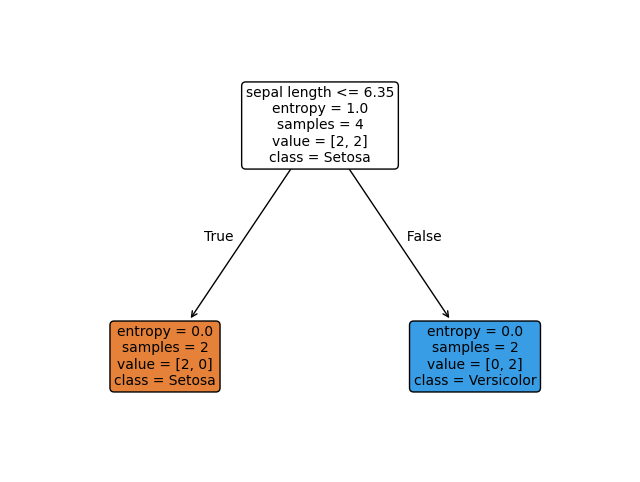


Predicted class for the new sample: Versicolor


/home/arch/coderly/ml/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [1]:
# Importing necessary libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Defining a smaller custom dataset
data = {
    'sepal length': [5.1, 4.9, 6.2, 5.9, 7.0, 6.5],
    'sepal width': [3.5, 3.0, 2.9, 3.0, 3.2, 3.0],
    'species': ['Setosa', 'Setosa', 'Versicolor', 'Versicolor', 'Virginica', 'Virginica']
}

# Convert the dictionary to a pandas DataFrame
df = pd.DataFrame(data)

# Print the dataset
print("Dataset:\n", df)

# Convert the target variable (species) to numeric labels
df['target'] = df['species'].map({'Setosa': 0, 'Versicolor': 1, 'Virginica': 2})

# Define the features and target
X = df[['sepal length', 'sepal width']]  # Features
y = df['target']  # Target variable

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of the Decision Tree: {accuracy * 100:.2f}%")

# Plotting the decision tree
plt.figure(figsize=(8, 6))
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=['Setosa', 'Versicolor', 'Virginica'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

# Classify a new sample (new flower data)
new_sample = [[5.0, 3.4]]  # Example: sepal length = 5.0, sepal width = 3.4
predicted_class = clf.predict(new_sample)

print("\nPredicted class for the new sample:", ['Setosa', 'Versicolor', 'Virginica'][predicted_class[0]])
